In [2]:
import pandas as pd

In [3]:
url = "https://docs.google.com/spreadsheets/d/1AjcqmM5kkCniTcL2gINvpiub-vefKA0nZR2Ln3eUFL8/export?format=csv"

df = pd.read_csv(url)

In [4]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [5]:
#Information required before starting the analysis
print("Info about the dataset:")
df.info()

Info about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [6]:
df['Review Date'] = pd.to_datetime(df['Review Date'])

df.dtypes

Review Id              object
Review                 object
Ratings                 int64
Review Date    datetime64[ns]
dtype: object

In [7]:
print("\nInfo about the data itself:")
df.describe()


Info about the data itself:


,Ratings,Review Date
count,196727.000000,196727
mean,4.503535,2024-03-25 22:03:05.784020736
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-06 09:47:07
50%,5.000000,2024-04-22 20:53:30
75%,5.000000,2024-06-24 16:43:04.500000
max,5.000000,2024-08-23 19:30:05
std,1.083004,NaN


In [8]:
print("\nNo. of duplicate rows in the dataset")
df.duplicated().sum()


No. of duplicate rows in the dataset


np.int64(2511)

In [9]:
print("\nNo. of null values in the dataset")
df.isnull().sum()


No. of null values in the dataset


Review Id      0
Review         6
Ratings        0
Review Date    0
dtype: int64

In [10]:
df[df['Review'].isnull()]

,Review Id,Review,Ratings,Review Date
35896,6d2f3aaa-babf-4105-9743-fa31462a526d,NaN,1,2024-07-11 18:15:05
49374,a6fc983e-8729-4d78-8cdf-25a47194932d,NaN,1,2024-06-24 06:20:22
155476,ffc32dd8-45b3-44a0-b8cf-8bd83ec5a621,NaN,1,2024-04-25 06:07:13
162561,527e0514-b444-4c59-b0a9-7f7774335ece,NaN,5,2024-04-04 18:56:52
169011,a16c4191-19e8-4cc2-b072-0118fae7b5f4,NaN,5,2024-03-23 23:03:54
169192,4c07a17f-5c2a-489b-8136-49fae85a6cfa,NaN,5,2024-03-29 13:52:29


In [11]:
df['Ratings'].value_counts().sort_index()

Ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64

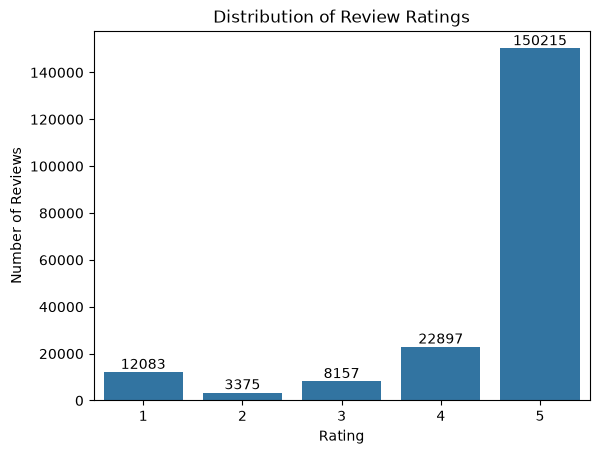

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.countplot(x='Ratings', data=df)

plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

ax.bar_label(ax.containers[0], fmt='%d')

plt.show()

In [13]:
print("Earliest review:", df['Review Date'].min())
print("Latest review:", df['Review Date'].max())

Earliest review: 2023-07-25 15:01:35
Latest review: 2024-08-23 19:30:05


In [14]:
monthly_reviews = df['Review Date'].dt.to_period('M').value_counts().sort_index()

monthly_reviews = monthly_reviews.reset_index()

monthly_reviews

,Review Date,count
0,2023-07,8283
1,2023-08,6801
2,2023-09,7593
3,2023-10,5824
4,2023-11,8719
5,2023-12,10375
6,2024-01,9313
7,2024-02,8748
8,2024-03,15175
9,2024-04,23739


In [18]:
monthly_reviews = monthly_reviews.rename(columns={'count': 'Review Count'})

monthly_reviews['Review Date'] = monthly_reviews['Review Date'].dt.to_timestamp()

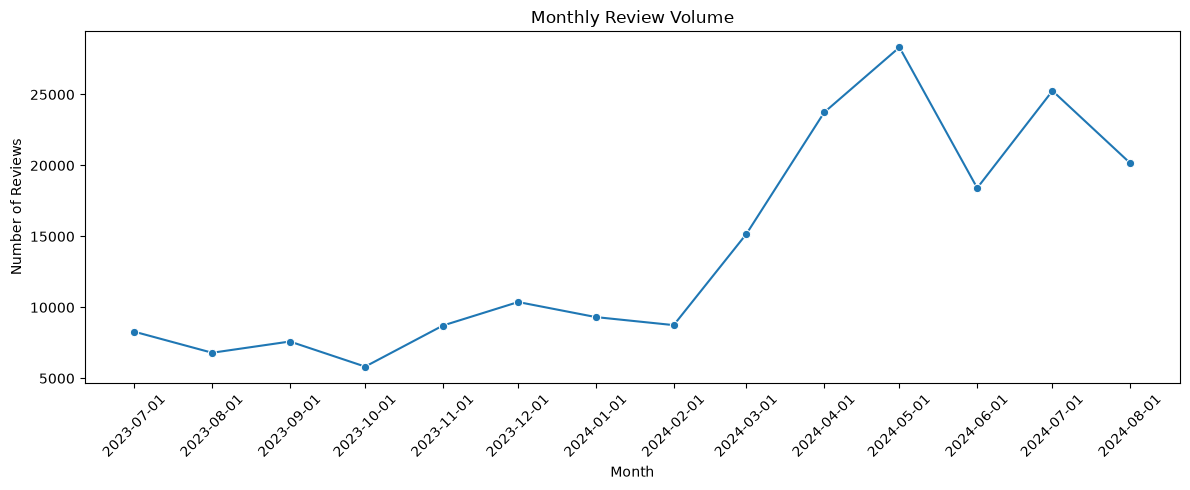

In [20]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_reviews,
    x='Review Date',
    y='Review Count',
    marker='o'
)

plt.title('Monthly Review Volume')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.xticks(monthly_reviews['Review Date'], rotation=45)
plt.tight_layout()

plt.show()